#  Customer Data Cleaning — Step by Step

## Goal

Clean the customer-level `Dataset.csv` reproducibly and create:

- a complete cleaned dataset;
- an analysis-ready dataset;
- a file containing records that require review; and
- a cleaning audit report.

The notebook preserves legitimate zero-spend and high-value records, flags rather than deletes statistical outliers, and never guesses missing dates or locations.

## Setup

Put this notebook and `CanadaVapesDataset.csv` in the same JupyterLab folder. The path cell also checks the previously used Windows download folders and supports the `DATA_FILE` environment variable.

Use **Kernel → Restart Kernel and Run All Cells**. Every variable is created in top-to-bottom order.

### Step 0: Import the required packages

In [ ]:
from __future__ import annotations

import os
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

### Step 1: File locations

In [ ]:
FILE_NAME = "Dataset.csv"


def find_data_file() -> Path:
    """Find the input file while allowing an explicit environment override."""
    candidates: list[Path] = []
    environment_path = os.environ.get("VAPES_DATA_FILE")
    if environment_path:
        candidates.append(Path(environment_path))

    candidates.extend(
        [
            Path.cwd() / FILE_NAME,
            Path.cwd() / "upload" / FILE_NAME,
            Path("C:/Users/tooko/Downloads/vape") / FILE_NAME,
            Path("C:/Users/tooko/Downloads/vape") / FILE_NAME,
        ]
    )

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    checked = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(
        f"Could not find {FILE_NAME}. Checked:\n{checked}\n"
        "Set VAPES_DATA_FILE to the full CSV path if it is elsewhere."
    )


DATA_FILE = find_data_file()
OUTPUT_FOLDER = DATA_FILE.parent

CLEANED_FILE = OUTPUT_FOLDER / "Vapes_cleaned.csv"
ANALYSIS_FILE = OUTPUT_FOLDER / "Vapes_analysis_ready.csv"
ISSUES_FILE = OUTPUT_FOLDER / "Vapes_quality_issues.csv"
REPORT_FILE = OUTPUT_FOLDER / "Vapes_cleaning_report.csv"

### Step 2: Reusable cleaning functions

In [ ]:
MISSING_TOKENS = {
    "",
    "-",
    "--",
    "n/a",
    "na",
    "nan",
    "none",
    "null",
    "unknown",
}

VALID_REGIONS = {
    "AB",
    "BC",
    "MB",
    "NB",
    "NL",
    "NS",
    "NT",
    "NU",
    "ON",
    "PE",
    "QC",
    "SK",
    "YT",
}


def clean_text(series: pd.Series) -> pd.Series:
    """Normalize Unicode and whitespace while preserving meaningful accents."""

    def normalize_value(value: object) -> object:
        if pd.isna(value):
            return pd.NA
        text = unicodedata.normalize("NFC", str(value))
        text = text.replace("\u00a0", " ")
        text = text.replace("’", "'").replace("`", "'")
        text = re.sub(r"\s+", " ", text).strip()
        if text.casefold() in MISSING_TOKENS:
            return pd.NA
        return text

    return series.map(normalize_value).astype("string")


def parse_number(series: pd.Series) -> pd.Series:
    """Parse currency, commas, parentheses, and spreadsheet apostrophes."""
    text = clean_text(series)
    text = text.str.replace(r"^'+", "", regex=True)
    negative_parentheses = text.str.match(r"^\(.*\)$", na=False)
    text = text.str.replace(r"^\((.*)\)$", r"\1", regex=True)
    text = text.str.replace(r"[$£€,%]", "", regex=True)
    text = text.str.replace(",", "", regex=False)
    values = pd.to_numeric(text, errors="coerce").astype("Float64")
    values.loc[negative_parentheses] = -values.loc[negative_parentheses].abs()
    return values


def city_key(value: object) -> object:
    """Create a matching key without changing the displayed city spelling."""
    if pd.isna(value):
        return pd.NA
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = text.casefold()
    text = re.sub(r"[^a-z0-9]+", " ", text).strip()
    return text if text else pd.NA


def improve_city_display(value: object) -> object:
    """Fix obvious all-upper/all-lower display text without inventing a city."""
    if pd.isna(value):
        return pd.NA
    text = str(value)
    text = re.sub(r"\s*-\s*", "-", text)
    if text.isupper() or text.islower():
        text = text.title()
        text = re.sub(r"'S\b", "'s", text)
    return text


def canonicalize_cities(city: pd.Series, region: pd.Series) -> pd.Series:
    """Use the most frequent spelling for equivalent cities within a region."""
    working = pd.DataFrame(
        {
            "city": clean_text(city).map(improve_city_display).astype("string"),
            "region": region.astype("string"),
        }
    )
    working["city_key"] = working["city"].map(city_key).astype("string")

    frequencies = (
        working.dropna(subset=["city", "region", "city_key"])
        .groupby(["region", "city_key", "city"], dropna=False)
        .size()
        .rename("frequency")
        .reset_index()
    )

    if frequencies.empty:
        return working["city"]

    # Prefer the most frequent spelling. In a tie, prefer the spelling with
    # accents because it normally preserves the official French city name.
    frequencies["accent_score"] = frequencies["city"].map(
        lambda x: sum(
            1
            for char in str(x)
            if unicodedata.normalize("NFKD", char) != char
        )
    )
    frequencies = frequencies.sort_values(
        ["region", "city_key", "frequency", "accent_score", "city"],
        ascending=[True, True, False, False, True],
    )
    canonical = frequencies.drop_duplicates(["region", "city_key"])[
        ["region", "city_key", "city"]
    ].rename(columns={"city": "canonical_city"})

    working = working.merge(
        canonical,
        on=["region", "city_key"],
        how="left",
        validate="many_to_one",
        sort=False,
    )
    return working["canonical_city"].fillna(working["city"]).astype("string")


def iqr_outlier_flag(series: pd.Series) -> tuple[pd.Series, float, float]:
    """Return a non-destructive IQR flag and its calculated limits."""
    valid = series.dropna().astype(float)
    if valid.empty:
        return pd.Series(False, index=series.index), np.nan, np.nan
    q1 = float(valid.quantile(0.25))
    q3 = float(valid.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flag = (series < lower) | (series > upper)
    return flag.fillna(False).astype(bool), lower, upper


def boolean_or(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    """Combine Boolean flag columns without nullable-Boolean ambiguity."""
    if not columns:
        return pd.Series(False, index=frame.index)
    return frame[columns].fillna(False).astype(bool).any(axis=1)

## Cleaning steps

### Step 3: Load and validate the schema

In [ ]:
raw = pd.read_csv(DATA_FILE, encoding="utf-8-sig", dtype="string")
original_rows = len(raw)
original_columns = list(raw.columns)

column_mapping = {
    "Last Active": "last_active",
    "Sign Up": "sign_up",
    "Orders": "orders",
    "Total Spend": "total_spend",
    "AOV": "reported_aov",
    "City": "city",
    "Region": "region",
}

missing_columns = sorted(set(column_mapping) - set(raw.columns))
if missing_columns:
    raise ValueError(
        "Required source columns are missing: " + ", ".join(missing_columns)
    )

df = raw[list(column_mapping)].rename(columns=column_mapping).copy()

### Step 4: Remove only exact duplicates and retain an auditable record identifier

In [ ]:
exact_duplicate_count = int(df.duplicated(keep="first").sum())
df = df.drop_duplicates(keep="first").reset_index(drop=True)
df.insert(0, "customer_record_id", [f"CV-{number:06d}" for number in range(1, len(df) + 1)])

### Step 5: Parse dates, amounts, counts, and location text

In [ ]:
df["last_active"] = pd.to_datetime(clean_text(df["last_active"]), errors="coerce")
df["sign_up"] = pd.to_datetime(clean_text(df["sign_up"]), errors="coerce")

orders_number = parse_number(df["orders"])
orders_array = orders_number.to_numpy(dtype=float, na_value=np.nan)
df["orders_missing_flag"] = orders_number.isna()
df["non_integer_orders_flag"] = pd.Series(
    ~np.isnan(orders_array)
    & ~np.isclose(orders_array, np.round(orders_array)),
    index=df.index,
)
df["negative_orders_flag"] = orders_number.lt(0).fillna(False)
df["orders"] = orders_number.round().astype("Int64")

df["total_spend"] = parse_number(df["total_spend"]).round(2)
df["reported_aov"] = parse_number(df["reported_aov"]).round(2)

df["region"] = clean_text(df["region"]).str.upper()
df["city"] = canonicalize_cities(df["city"], df["region"])

### Step 6: Validate cross-field business rules and calculate a reliable AOV

In [ ]:
df["last_active_missing_flag"] = df["last_active"].isna()
df["sign_up_missing_flag"] = df["sign_up"].isna()
df["city_missing_flag"] = df["city"].isna()
df["region_missing_flag"] = df["region"].isna()
df["invalid_region_flag"] = df["region"].notna() & ~df["region"].isin(VALID_REGIONS)

today = pd.Timestamp.now().normalize()
df["future_last_active_flag"] = df["last_active"].dt.normalize().gt(today).fillna(False)
df["future_sign_up_flag"] = df["sign_up"].dt.normalize().gt(today).fillna(False)

same_calendar_day = (
    df["last_active"].notna()
    & df["sign_up"].notna()
    & df["last_active"].dt.normalize().eq(df["sign_up"].dt.normalize())
)
df["same_day_timestamp_sequence_flag"] = (
    same_calendar_day & df["last_active"].lt(df["sign_up"])
)
df["last_active_before_signup_flag"] = (
    df["last_active"].notna()
    & df["sign_up"].notna()
    & df["last_active"].dt.normalize().lt(df["sign_up"].dt.normalize())
)

df["total_spend_missing_flag"] = df["total_spend"].isna()
df["reported_aov_missing_flag"] = df["reported_aov"].isna()
df["negative_total_spend_flag"] = df["total_spend"].lt(0).fillna(False)
df["negative_aov_flag"] = df["reported_aov"].lt(0).fillna(False)
df["zero_spend_with_orders_flag"] = (
    df["orders"].gt(0).fillna(False) & df["total_spend"].eq(0).fillna(False)
)

valid_aov_denominator = df["orders"].gt(0).fillna(False)
df["calculated_aov"] = (
    df["total_spend"].div(df["orders"].where(valid_aov_denominator)).round(2)
)
df["aov_difference"] = (df["reported_aov"] - df["calculated_aov"]).abs().round(2)
df["aov_mismatch_flag"] = df["aov_difference"].gt(0.01).fillna(False)

# The calculated AOV is authoritative because it is reproducible from the two
# underlying fields. Reported AOV remains in the output for auditing.
df["aov"] = df["calculated_aov"]

### Step 7: Add useful time fields and non-destructive statistical outlier flags

In [ ]:
snapshot_date = df["last_active"].max().normalize()
df["days_since_last_active"] = (
    snapshot_date - df["last_active"].dt.normalize()
).dt.days.astype("Int64")
df["customer_tenure_days"] = (
    df["last_active"].dt.normalize() - df["sign_up"].dt.normalize()
).dt.days.astype("Int64")
df.loc[df["customer_tenure_days"].lt(0), "customer_tenure_days"] = pd.NA

df["orders_outlier_flag"], orders_lower, orders_upper = iqr_outlier_flag(df["orders"])
df["total_spend_outlier_flag"], spend_lower, spend_upper = iqr_outlier_flag(df["total_spend"])
df["aov_outlier_flag"], aov_lower, aov_upper = iqr_outlier_flag(df["aov"])
df["statistical_outlier_flag"] = boolean_or(
    df,
    ["orders_outlier_flag", "total_spend_outlier_flag", "aov_outlier_flag"],
)

### Step 8: Build review and analysis-readiness indicators

In [ ]:
quality_flag_columns = [
    "last_active_missing_flag",
    "sign_up_missing_flag",
    "orders_missing_flag",
    "non_integer_orders_flag",
    "negative_orders_flag",
    "total_spend_missing_flag",
    "reported_aov_missing_flag",
    "city_missing_flag",
    "region_missing_flag",
    "invalid_region_flag",
    "future_last_active_flag",
    "future_sign_up_flag",
    "last_active_before_signup_flag",
    "negative_total_spend_flag",
    "negative_aov_flag",
    "zero_spend_with_orders_flag",
    "aov_mismatch_flag",
]

df["data_quality_issue"] = boolean_or(df, quality_flag_columns)

core_exclusion_columns = [
    "last_active_missing_flag",
    "orders_missing_flag",
    "non_integer_orders_flag",
    "negative_orders_flag",
    "total_spend_missing_flag",
    "reported_aov_missing_flag",
    "negative_total_spend_flag",
    "negative_aov_flag",
]
df["analysis_exclusion_flag"] = boolean_or(df, core_exclusion_columns)
df["record_quality_status"] = np.select(
    [df["analysis_exclusion_flag"], df["data_quality_issue"], df["statistical_outlier_flag"]],
    ["Exclude from monetary analysis", "Review", "Valid statistical outlier"],
    default="Clean",
)

### Step 9: Arrange columns and create outputs

In [ ]:
core_columns = [
    "customer_record_id",
    "last_active",
    "sign_up",
    "orders",
    "total_spend",
    "aov",
    "reported_aov",
    "calculated_aov",
    "aov_difference",
    "city",
    "region",
    "days_since_last_active",
    "customer_tenure_days",
    "record_quality_status",
    "data_quality_issue",
    "analysis_exclusion_flag",
    "statistical_outlier_flag",
]

flag_columns = [
    column
    for column in df.columns
    if column.endswith("_flag") and column not in core_columns
]

df = df[core_columns + sorted(flag_columns)]
analysis_ready = df.loc[~df["analysis_exclusion_flag"]].copy()
quality_issues = df.loc[df["data_quality_issue"]].copy()

for output in (df, analysis_ready, quality_issues):
    output["total_spend"] = output["total_spend"].round(2)
    output["aov"] = output["aov"].round(2)
    output["reported_aov"] = output["reported_aov"].round(2)
    output["calculated_aov"] = output["calculated_aov"].round(2)
    output["aov_difference"] = output["aov_difference"].round(2)

df.to_csv(CLEANED_FILE, index=False, encoding="utf-8-sig", date_format="%Y-%m-%d %H:%M:%S")
analysis_ready.to_csv(
    ANALYSIS_FILE,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d %H:%M:%S",
)
quality_issues.to_csv(
    ISSUES_FILE,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d %H:%M:%S",
)

## Checks and saved outputs

### Step 10: Create a concise cleaning report

In [ ]:
def report_row(metric: str, count: int | float, note: str) -> dict[str, object]:
    rate = float(count) / len(df) if len(df) else np.nan
    return {"metric": metric, "count": count, "rate": rate, "note": note}


report_rows = [
    report_row("original_rows", original_rows, "Rows read from the source file."),
    report_row("exact_duplicates_removed", exact_duplicate_count, "Only exact duplicate rows were removed."),
    report_row("cleaned_rows", len(df), "All retained records in the cleaned output."),
    report_row("analysis_ready_rows", len(analysis_ready), "Rows suitable for monetary/customer analysis."),
    report_row("quality_issue_rows", len(quality_issues), "Rows with at least one substantive quality flag."),
]

flag_notes = {
    "sign_up_missing_flag": "Signup date is unavailable; it was not imputed.",
    "last_active_before_signup_flag": "Last-active date is earlier than signup date at calendar-day level.",
    "same_day_timestamp_sequence_flag": "Same-day last-active timestamp precedes signup time; retained as a low-severity source precision issue.",
    "city_missing_flag": "City is unavailable; it was not guessed.",
    "region_missing_flag": "Region is unavailable; it was not guessed.",
    "invalid_region_flag": "Region is outside the Canadian province/territory code list.",
    "zero_spend_with_orders_flag": "Positive order count with zero lifetime spend; retained for refund/free-order review.",
    "negative_total_spend_flag": "Negative lifetime spend parsed correctly and excluded from monetary analysis.",
    "aov_mismatch_flag": "Reported AOV differs from Total Spend / Orders by more than one cent.",
    "orders_outlier_flag": f"Non-destructive IQR flag; limits {orders_lower:.2f} to {orders_upper:.2f}.",
    "total_spend_outlier_flag": f"Non-destructive IQR flag; limits {spend_lower:.2f} to {spend_upper:.2f}.",
    "aov_outlier_flag": f"Non-destructive IQR flag; limits {aov_lower:.2f} to {aov_upper:.2f}.",
}

for flag in sorted(flag_columns):
    report_rows.append(
        report_row(
            flag,
            int(df[flag].fillna(False).astype(bool).sum()),
            flag_notes.get(flag, "Automated validation flag."),
        )
    )

report = pd.DataFrame(report_rows)
report.to_csv(REPORT_FILE, index=False, encoding="utf-8-sig")

### Step 11: Terminal/Jupyter output

In [ ]:
print("=" * 68)
print("CUSTOMER DATA CLEANING COMPLETE")
print("=" * 68)
print(f"Input file:              {DATA_FILE}")
print(f"Original rows:           {original_rows:,}")
print(f"Exact duplicates removed:{exact_duplicate_count:>9,}")
print(f"Cleaned rows:            {len(df):,}")
print(f"Analysis-ready rows:     {len(analysis_ready):,}")
print(f"Quality-issue rows:      {len(quality_issues):,}")
print(f"Dataset snapshot date:   {snapshot_date.date()}")
print("\nSaved files:")
for path in (CLEANED_FILE, ANALYSIS_FILE, ISSUES_FILE, REPORT_FILE):
    print(f"  {path}")

print("\nQuality flag totals:")
print(
    df[quality_flag_columns]
    .sum()
    .sort_values(ascending=False)
    .to_string()
)

print("\nCleaned preview:")
preview_columns = [
    "customer_record_id",
    "last_active",
    "sign_up",
    "orders",
    "total_spend",
    "aov",
    "city",
    "region",
    "record_quality_status",
]
print(df[preview_columns].head().to_string(index=False))

CUSTOMER DATA CLEANING COMPLETE
Input file:              /workspace/scratch/392f36e0de90/upload/CanadaVapesDataset.csv
Original rows:           30,804
Exact duplicates removed:        0
Cleaned rows:            30,804
Analysis-ready rows:     30,803
Quality-issue rows:      293
Dataset snapshot date:   2026-07-08

Saved files:
  /workspace/scratch/392f36e0de90/upload/Vapes_cleaned.csv
  /workspace/scratch/392f36e0de90/upload/Vapes_analysis_ready.csv
  /workspace/scratch/392f36e0de90/upload/Vapes_quality_issues.csv
  /workspace/scratch/392f36e0de90/upload/Vapes_cleaning_report.csv

Quality flag totals:
zero_spend_with_orders_flag       157
region_missing_flag                69
city_missing_flag                  68
sign_up_missing_flag               48
last_active_before_signup_flag     26
negative_aov_flag                   1
negative_total_spend_flag           1
last_active_missing_flag            0
orders_missing_flag                 0
total_spend_missing_flag            0
reported_ao

### Step 12: Validate the cleaned results

In [ ]:
# These assertions stop the notebook if a core cleaning guarantee fails.
assert df["customer_record_id"].is_unique
assert len(df) == original_rows - exact_duplicate_count
assert not analysis_ready["analysis_exclusion_flag"].any()
assert not analysis_ready["total_spend"].lt(0).any()
assert not analysis_ready["aov"].lt(0).any()
assert df.loc[df["orders"].gt(0), "aov"].notna().all()

validation_summary = pd.DataFrame(
    {
        "check": [
            "Cleaned rows",
            "Analysis-ready rows",
            "Quality-issue rows",
            "Exact duplicates removed",
            "Unique generated record IDs",
            "Negative monetary rows excluded from analysis-ready output",
        ],
        "result": [
            f"{len(df):,}",
            f"{len(analysis_ready):,}",
            f"{len(quality_issues):,}",
            f"{exact_duplicate_count:,}",
            "Passed",
            "Passed",
        ],
    }
)
display(validation_summary)

                                                     check result
                                              Cleaned rows 30,804
                                       Analysis-ready rows 30,803
                                        Quality-issue rows    293
                                  Exact duplicates removed      0
                               Unique generated record IDs Passed
Negative monetary rows excluded from analysis-ready output Passed


### Step 13: Visualize the quality flags

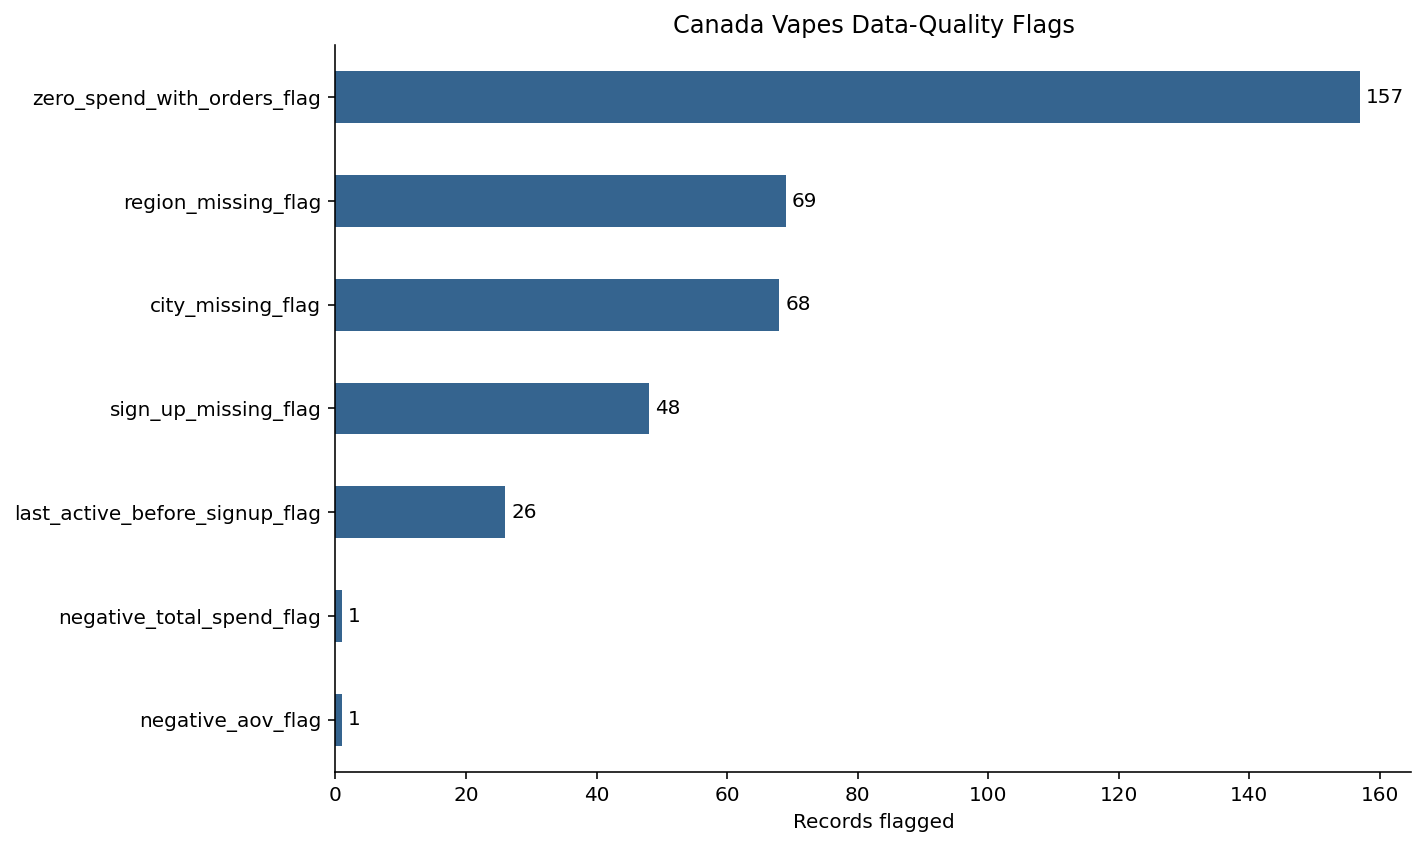

In [ ]:
import matplotlib.pyplot as plt

quality_counts = (
    df[quality_flag_columns]
    .sum()
    .sort_values(ascending=True)
)
quality_counts = quality_counts[quality_counts.gt(0)]

fig, ax = plt.subplots(figsize=(10, 6))
quality_counts.plot(kind="barh", color="#35648f", ax=ax)
ax.set_title(" Data-Quality Flags")
ax.set_xlabel("Records flagged")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
QUALITY_CHART_FILE = OUTPUT_FOLDER / "quality_flags.png"
fig.savefig(QUALITY_CHART_FILE, dpi=144, bbox_inches="tight")
plt.show()

## Next steps

- Use `analysis_ready.csv` for customer segmentation, retention analysis, forecasting, and monetary summaries.
- Use `cleaned.csv` when an audit trail and all source records are required.
- Review `quality_issues.csv` before using signup-date, city, region, or zero-spend fields operationally.
- The generated `customer_record_id` is a row identifier, not a true customer ID. Do not use it to merge this export with another system.